In [2]:
from osgeo import gdal
import numpy as np
import cv2
import matplotlib.pyplot as plt

**CALCULANDO ÁREA UTIL DE PLANTAÇÃO**

2
Pixels dentro da máscara: 579803
Área em unidades do raster: 1449.5075000000004
Área em hectares: 0.14495075000000004


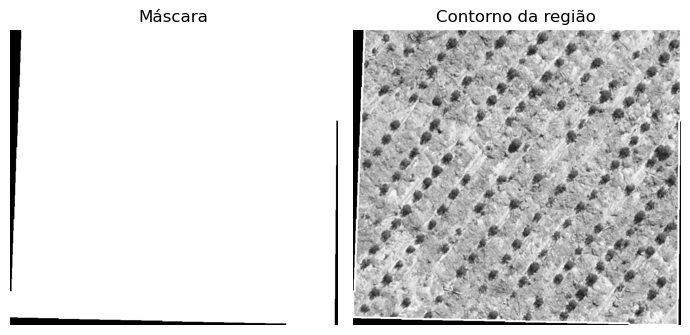

In [19]:
path_amostra_padronizada = '../data/processed/sample1_padronizado.tif'

src = gdal.Open(path_amostra_padronizada, gdal.GA_ReadOnly)
gt = src.GetGeoTransform()

img_gray = src.ReadAsArray()
print(img_gray.ndim)

TH_BLACK = 10
mask_keep = (img_gray > TH_BLACK).astype(np.uint8) * 255  # 255 = não-preto

kernel = np.ones((7, 7), np.uint8)
mask_keep = cv2.morphologyEx(mask_keep, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(mask_keep, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contorno = img_gray.copy()
cv2.drawContours(img_contorno, contours, -1, (255, 255, 255), 3)

num_pixels = np.count_nonzero(mask_keep)
print("Pixels dentro da máscara:", num_pixels)

pixel_width = abs(gt[1])
pixel_height = abs(gt[5])

pixel_area = pixel_width * pixel_height
area_total = num_pixels * pixel_area

print("Área em unidades do raster:", area_total)

area_ha = area_total / 10000
print("Área em hectares:", area_ha)

plt.figure(figsize=(7, 7))

plt.subplot(1, 2, 1)
plt.title("Máscara")
plt.imshow(mask_keep, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Contorno da região")
plt.imshow(img_contorno, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

